In [22]:
import torch
import torch.nn as nn
import torch.optim as optim

from torchvision import datasets, transforms, models
from datetime import datetime
from torch.utils.data import DataLoader

from pathlib import Path
import random
import numpy as np
import pandas as pd
import os
import json
import time
import copy
import matplotlib.pyplot as plt
from tqdm.auto import tqdm  # Auto-detect Jupyter / Terminal

from torchvision.models import resnet50, ResNet50_Weights
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

In [23]:
# Memastikan CUDA (GPU) tersedia
if torch.cuda.is_available():
    device = torch.device("cuda")
    print(f"GPU terdeteksi: {torch.cuda.get_device_name(0)}")
else:
    device = torch.device("cpu")
    print("GPU tidak terdeteksi, menggunakan CPU.")

GPU terdeteksi: NVIDIA GeForce RTX 4060 Laptop GPU


## Konfigurasi

In [24]:
# ==============================================================================
# 1. PENGATURAN SEED (REPRODUCIBILITY)
# Tujuannya agar jika eksperimen diulang, hasilnya akan tetap sama (konsisten)
# ==============================================================================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        # Mengatur agar backend CuDNN berjalan deterministik
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

In [25]:
# ==============================================================================
# 1. KONFIGURASI PATH (FOLDER DIRECTORY)
# ==============================================================================
# Sesuaikan 'dataset/' dengan nama folder tempat Anda menyimpan data
CURRENT_DIR     = Path.cwd()

if CURRENT_DIR.name == "cnn_svm":
    PROJECT_DIR = CURRENT_DIR.parent
else:
    PROJECT_DIR = CURRENT_DIR

Eksperimen = 1

OUTPUT_DIR       = CURRENT_DIR  / "dataset" 
OUTPUT_MODEL     = CURRENT_DIR  / f"Eksperimen_{Eksperimen}" / "models" 
TRAIN_MODEL_DIR  = OUTPUT_MODEL / "train"
TEST_MODEL_DIR   = OUTPUT_MODEL / "test"

LOG_DIR = CURRENT_DIR  / f"Eksperimen_{Eksperimen}" / "logs" 
LOG_TRAIN = LOG_DIR / "train"
LOG_TEST = LOG_DIR / "test"

TRAIN_DIR       = OUTPUT_DIR / "train"
VAL_DIR         = OUTPUT_DIR / "val"
TEST_DIR        = OUTPUT_DIR / "test"
MODEL_SAVE_PATH = OUTPUT_MODEL / f'best_cloud_model_CNN_Eksperimen_{Eksperimen}.pth' # Nama file ketika model disimpan nanti

OUTPUT_MODEL.mkdir(parents=True, exist_ok=True)
TRAIN_MODEL_DIR.mkdir(parents=True, exist_ok=True)
TEST_MODEL_DIR.mkdir(parents=True, exist_ok=True)
LOG_TRAIN.mkdir(parents=True, exist_ok=True)
LOG_TEST.mkdir(parents=True, exist_ok=True)

In [26]:
# ==============================================================================
# 1. KONFIGURASI DATASET & DATALOADER
# ==============================================================================
NUM_CLASSES     = 7
IMAGE_SIZE      = 224 # Standar untuk ResNet, MobileNet, dll (224x224)
BATCH_SIZE      = 32  # Turunkan ke 16 atau 8 jika GPU lokal mengalami "Out of Memory"
NUM_WORKERS     = 0   # Gunakan 2 atau 4 (sesuai jumlah core CPU lokal Anda)
HASIL_TRAIN     = [] 
HASIL_TEST      = []

## Transformasi, Dataset, dan DataLoader

In [27]:
# 1. Setup Transformasi Data
# Normalisasi menggunakan rata-rata dan standar deviasi dari ImageNet
data_transforms = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) 
])

In [28]:
# 2. Inisialisasi Dataset menggunakan variabel Pathlib
# PyTorch ImageFolder menerima objek Pathlib tanpa perlu diubah menjadi string
train_dataset = datasets.ImageFolder(root=TRAIN_DIR, transform=data_transforms)
val_dataset   = datasets.ImageFolder(root=VAL_DIR, transform=data_transforms)
test_dataset  = datasets.ImageFolder(root=TEST_DIR, transform=data_transforms)

# Mengekstrak nama kelas
class_names = train_dataset.classes

# 3. Setup DataLoader
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=NUM_WORKERS, pin_memory=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS, pin_memory=True)

# Catatan: pin_memory=True digunakan untuk mempercepat transfer data dari CPU RAM ke GPU VRAM.


In [29]:
# ==============================================================================
# 2. KONFIGURASI MODEL & TRAINING (HYPERPARAMETERS)
# ==============================================================================
DILATION_CONV3 = 2  # Besar dilation yang digunakan pada Conv3.
MODEL_NAME = f"baseline_CNN_conv3_d{DILATION_CONV3}"
WEIGHTS_MODEL   = 'ResNet50_Weights.IMAGENET1K_V2'
LEARNING_RATE   = 1e-5        # 0.0001 (LR kecil bagus untuk pre-trained model/fine-tuning)
EPOCHS          = 40          # Jumlah iterasi training
SEED_VALUE      = 42          # Angka seed standar
PATIENCE        = 5           # EARLY STOPPING

In [30]:
# FUNCTION: Membuat blok konvolusi fleksibel & modular
def buat_blok_konvolusi(
    in_channels, 
    out_channels, 
    kernel_size, 
    stride=1, 
    padding=0, 
    jumlah_conv=1, 
    inplace=True, 
    lrn=None, 
    pool=None,  # Opsional: tuple (kernel_size, stride, padding) atau Bool
    dilation=1
):
    layers = []
    
    # Konfigurasi LRN default jika lrn=True dikirim
    default_lrn = {
        "status": True,
        "size": 5,
        "alpha": 0.0001,
        "beta": 0.75,
        "k": 1.0
    }
    
    if lrn is True:
        lrn_config = default_lrn
    elif isinstance(lrn, dict):
        lrn_config = lrn
    else:
        lrn_config = None

    current_in = in_channels
    for i in range(jumlah_conv):
        current_out = out_channels[i] if isinstance(out_channels, (list, tuple)) else out_channels
        # Stride besar hanya diterapkan pada konvolusi pertama jika jumlah_conv > 1
        current_stride = stride if i == 0 else 1
        
        layers.append(
            nn.Conv2d(
                in_channels=current_in,
                out_channels=current_out,
                kernel_size=kernel_size,
                stride=current_stride,
                padding=padding,
                dilation=dilation
            )
        )
        layers.append(nn.ReLU(inplace=inplace))
        current_in = current_out
    
    # Tambahkan LRN jika dikonfigurasi dan status True
    if lrn_config and lrn_config.get("status", False):
        layers.append(
            nn.LocalResponseNorm(
                size=lrn_config.get("size", 5),
                alpha=lrn_config.get("alpha", 0.0001),
                beta=lrn_config.get("beta", 0.75),
                k=lrn_config.get("k", 1.0)
            )
        )

    # Tambahkan Max Pooling jika dikonfigurasi
    if pool:
        if isinstance(pool, tuple):
            pk = pool[0]
            ps = pool[1] if len(pool) > 1 else pk
            pp = pool[2] if len(pool) > 2 else 0
            layers.append(nn.MaxPool2d(kernel_size=pk, stride=ps, padding=pp))
        elif pool is True:
            layers.append(nn.MaxPool2d(kernel_size=3, stride=2, padding=0))

    return nn.Sequential(*layers)


class CNNBaseline(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dilation_conv3=1):
        super(CNNBaseline, self).__init__()

        self.dilation_conv3 = dilation_conv3

        lrn_config = {
            "status": True,
            "size": 5,
            "alpha": 0.0001,
            "beta": 0.75,
            "k": 1.0
        }
        
        self.features = nn.Sequential(
            # Conv1: 96 filter (11x11, s=4, p=0) + LRN + MaxPool(3x3, s=2)
            buat_blok_konvolusi(
                in_channels=3, 
                out_channels=96, 
                kernel_size=11, 
                stride=4, 
                padding=0, 
                inplace=True, 
                lrn=lrn_config, 
                pool=(3, 2, 0)
            ),
            
            # Conv2: 256 filter (5x5, s=1, p=2) + LRN + MaxPool(3x3, s=2)
            buat_blok_konvolusi(
                in_channels=96, 
                out_channels=256, 
                kernel_size=5, 
                stride=1, 
                padding=2, 
                inplace=True, 
                lrn=lrn_config, 
                pool=(3, 2, 0)
            ),

            # Conv3: 384 filter (3x3, s=1, p=1) -> Tanpa LRN & Pool
            buat_blok_konvolusi(
                in_channels=256, 
                out_channels=384, 
                kernel_size=3, 
                stride=1, 
                padding=self.dilation_conv3, 
                dilation=self.dilation_conv3, 
                inplace=True
            ),
            
            # Conv4: 384 filter (3x3, s=1, p=1) -> Tanpa LRN & Pool
            buat_blok_konvolusi(
                in_channels=384, 
                out_channels=384, 
                kernel_size=3, 
                stride=1, 
                padding=1, 
                inplace=True
            ),
            
            # Conv5: 256 filter (3x3, s=1, p=1) + MaxPool(3x3, s=2)
            buat_blok_konvolusi(
                in_channels=384, 
                out_channels=256, 
                kernel_size=3, 
                stride=1, 
                padding=1, 
                inplace=True, 
                pool=(3, 2, 0)
            )
        )

        # Classifier / Fully Connected Layers
        self.classifier = nn.Sequential(
            # 1. Penyesuaian Spasial & Flattening
            nn.AdaptiveAvgPool2d((6, 6)), # Memastikan output fitur selalu 7x7
            nn.Flatten(),                 # Mengubah [Batch, 512, 7, 7] menjadi [Batch, 25088]

            # 2. FC6
            nn.Linear(256 * 6 * 6, 4096),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),             # Regularisasi cegah overfitting

            # 3. FC7
            nn.Linear(4096, 2048),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),

            # 4. FC8 (Intermediat / Layer Kompresi 1000)
            nn.Linear(2048, 1000),
            nn.ReLU(inplace=True),

            # 5. FC9 (Output Logits Klasifikasi)
            nn.Linear(1000, num_classes)   # Tanpa ReLU agar nilai logits valid untuk CrossEntropyLoss
        )

    def forward(self, x):
        x = self.features(x)
        scores = self.classifier(x)   # Menghasilkan skor berukuran [N, num_classes].
        return scores  
    

In [31]:
# model = CNNBaseline(num_classes=NUM_CLASSES).to(device)
# print(model)

set_seed(SEED_VALUE)

model = CNNBaseline(
    num_classes=NUM_CLASSES,
    dilation_conv3=DILATION_CONV3,
).to(device)

print(model)

CNNBaseline(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 96, kernel_size=(11, 11), stride=(4, 4))
      (1): ReLU(inplace=True)
      (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=1.0)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(96, 256, kernel_size=(5, 5), stride=(1, 1), padding=(2, 2))
      (1): ReLU(inplace=True)
      (2): LocalResponseNorm(5, alpha=0.0001, beta=0.75, k=1.0)
      (3): MaxPool2d(kernel_size=3, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(256, 384, kernel_size=(3, 3), stride=(1, 1), padding=(2, 2), dilation=(2, 2))
      (1): ReLU(inplace=True)
    )
    (3): Sequential(
      (0): Conv2d(384, 384, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(inplace=True)
    )
    (4): Sequential(
      (0): Conv2d(384, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): ReLU(in

In [32]:
num_epochs = EPOCHS
patience = PATIENCE
criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(model.parameters(), lr=LEARNING_RATE)

In [33]:
def train_one_epoch(model, train_loader, criterion, optimizer, device):
    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [34]:
def validate_one_epoch(model, val_loader, criterion, device):
    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for images, labels in val_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)
            correct += (predicted == labels).sum().item()
            total += labels.size(0)

    epoch_loss = running_loss / total
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [35]:

hasil_train = history = {
    "epoch": [],
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "timestamp": []
}

best_val_loss = float("inf")
patience_counter = 0

best_model_path = (
    TRAIN_MODEL_DIR / f"best_cloud_model_{MODEL_NAME}.pth"
)

print("\nMemulai Pelatihan...")
for epoch in range(num_epochs):

    print(f"\n{'='*50}")
    print(f"MEMASUKI Epochs {epoch+1} | Max Epochs: {num_epochs} | Target LR: {LEARNING_RATE}")
    print(f"{'='*50}")

    train_loss, train_acc = train_one_epoch(
        model, train_loader, criterion, optimizer, device
    )

    val_loss, val_acc = validate_one_epoch(
        model, val_loader, criterion, device
    )

    history["epoch"].append({epoch+1}) 
    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(train_acc)
    history["val_acc"].append(val_acc)
    history["timestamp"].append(datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        patience_counter = 0

        torch.save({
            "epoch": epoch + 1,
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
            "best_val_loss": best_val_loss,
            "dilation_conv3": model.dilation_conv3,    
            "class_names": train_dataset.classes,
            "model_name": MODEL_NAME
        }, best_model_path)

        print("Model terbaik disimpan.")
    else:
        patience_counter += 1
        print(f"Early stopping counter: {patience_counter}/{patience}")

    if patience_counter >= patience:
        print("Training dihentikan karena early stopping.")
        break

    print(f"{'='*50}")


Memulai Pelatihan...

MEMASUKI Epochs 1 | Max Epochs: 40 | Target LR: 1e-05
Epoch [1/40] Train Loss: 1.0043 | Train Acc: 0.6005 | Val Loss: 0.6792 | Val Acc: 0.7282
Model terbaik disimpan.

MEMASUKI Epochs 2 | Max Epochs: 40 | Target LR: 1e-05
Epoch [2/40] Train Loss: 0.6860 | Train Acc: 0.7410 | Val Loss: 0.7051 | Val Acc: 0.7482
Early stopping counter: 1/5

MEMASUKI Epochs 3 | Max Epochs: 40 | Target LR: 1e-05
Epoch [3/40] Train Loss: 0.5659 | Train Acc: 0.7878 | Val Loss: 0.5139 | Val Acc: 0.8084
Model terbaik disimpan.

MEMASUKI Epochs 4 | Max Epochs: 40 | Target LR: 1e-05
Epoch [4/40] Train Loss: 0.5042 | Train Acc: 0.8120 | Val Loss: 0.4044 | Val Acc: 0.8425
Model terbaik disimpan.

MEMASUKI Epochs 5 | Max Epochs: 40 | Target LR: 1e-05
Epoch [5/40] Train Loss: 0.4623 | Train Acc: 0.8271 | Val Loss: 0.4537 | Val Acc: 0.8265
Early stopping counter: 1/5

MEMASUKI Epochs 6 | Max Epochs: 40 | Target LR: 1e-05
Epoch [6/40] Train Loss: 0.4369 | Train Acc: 0.8357 | Val Loss: 0.3937 | Va

In [39]:
import json
import time

Berhasil menyimpan log ke 'd:\n8n-logsiswaparalayang\cloud-classification\cnn_svm\Eksperimen_1\logs\train\log_train_baseline_CNN_conv3_d2.json'
Berhasil menyimpan tabel ke 'd:\n8n-logsiswaparalayang\cloud-classification\cnn_svm\Eksperimen_1\logs\train\tabel_log_train_baseline_CNN_conv3_d2.csv'


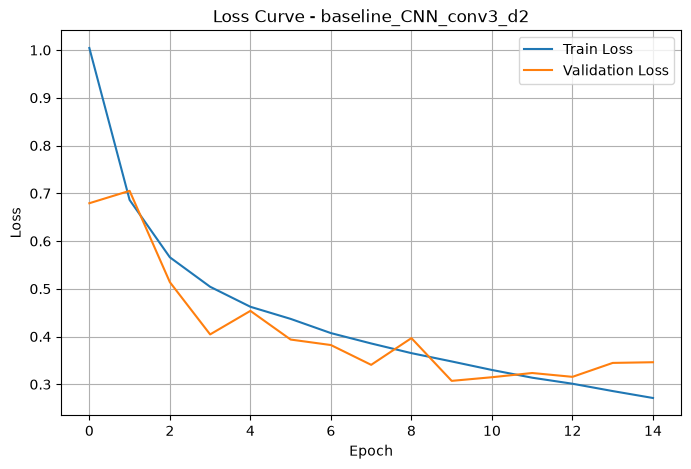

In [40]:
def convert_to_serializable(obj):
    if isinstance(obj, set):
        return list(obj)
    if isinstance(obj, (np.integer, np.floating)):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    raise TypeError(f"Type {type(obj)} not serializable")

json_path = LOG_TRAIN / f"log_train_{MODEL_NAME}.json"
with open(json_path, "w", encoding="utf-8") as json_file:
    json.dump(history, json_file, indent=4, ensure_ascii=False, default=convert_to_serializable)

print(f"Berhasil menyimpan log ke '{json_path}'")
csv_path = LOG_TRAIN / f"tabel_log_train_{MODEL_NAME}.csv"
summary_train = pd.DataFrame(history)
summary_train.to_csv(csv_path, index=False)
print(f"Berhasil menyimpan tabel ke '{csv_path}'")

plt.figure(figsize=(8, 5))
plt.plot(history["train_loss"], label="Train Loss")
plt.plot(history["val_loss"], label="Validation Loss")
plt.title(f"Loss Curve - {MODEL_NAME}")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.savefig(LOG_TRAIN / f"loss_curve_{MODEL_NAME}.png", dpi=300, bbox_inches="tight")
plt.show()


Model terbaik berhasil dimuat
Epoch terbaik: 10
Validation loss terbaik: 0.30714940050301126
Sedang mengevaluasi data test, mohon tunggu...


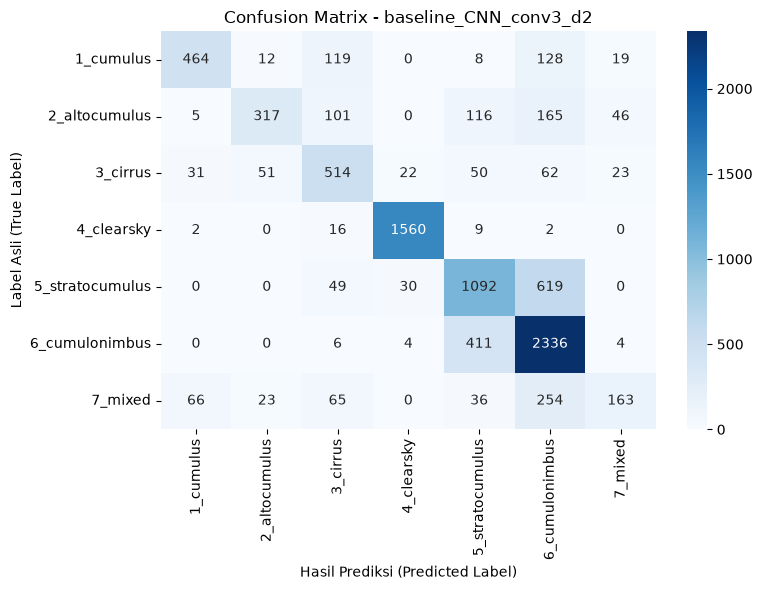


=== CLASSIFICATION REPORT ===
                 precision    recall  f1-score   support

      1_cumulus       0.82      0.62      0.70       750
  2_altocumulus       0.79      0.42      0.55       750
       3_cirrus       0.59      0.68      0.63       753
     4_clearsky       0.97      0.98      0.97      1589
5_stratocumulus       0.63      0.61      0.62      1790
 6_cumulonimbus       0.66      0.85      0.74      2761
        7_mixed       0.64      0.27      0.38       607

       accuracy                           0.72      9000
      macro avg       0.73      0.63      0.66      9000
   weighted avg       0.72      0.72      0.71      9000



In [41]:
best_model_path = (
    TRAIN_MODEL_DIR / f"best_cloud_model_{MODEL_NAME}.pth"
)
checkpoint = torch.load(best_model_path, map_location=device)

model = CNNBaseline(
    num_classes=NUM_CLASSES,
    dilation_conv3=checkpoint["dilation_conv3"],
).to(device)
model.load_state_dict(checkpoint["model_state_dict"])

model.eval()

print("Model terbaik berhasil dimuat")
print("Epoch terbaik:", checkpoint["epoch"])
print("Validation loss terbaik:", checkpoint["best_val_loss"])

# ==========================================
# 3. PROSES PREDIKSI DATA TEST
# ==========================================
all_preds = []
all_labels = []

print("Sedang mengevaluasi data test, mohon tunggu...")
with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        outputs = model(images)
        
        _, preds = torch.max(outputs, 1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.numpy())

# ==========================================
# 4. HITUNG & TAMPILKAN CONFUSION MATRIX
# ==========================================
cm = confusion_matrix(all_labels, all_preds)

# Visualisasi menggunakan Seaborn Heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title(f"Confusion Matrix - {MODEL_NAME}")
plt.ylabel('Label Asli (True Label)')
plt.xlabel('Hasil Prediksi (Predicted Label)')
plt.tight_layout()

# Simpan hasil gambar matrix
plt.savefig(
    LOG_TEST / f"confusion_matrix_{MODEL_NAME}.png",
    dpi=300
)
plt.show()

# ==========================================
# 5. CETAK CLASSIFICATION REPORT (METRIK TAMBAHAN)
# ==========================================
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(all_labels, all_preds, target_names=class_names))
